Load common processed data (per cycle)

SOC label computation (Coulomb counting)
This code performs Coulomb Counting to estimate the State of Charge (SoC) for different battery cycles (identified by cid). It starts with the assumption that the battery is fully charged (represented by the 1) and then subtracts the cumulative energy removed over time. By taking the cumulative sum (cumsum) of the measured current and multiplying it by the time step (DT), it calculates the total Ampere-seconds discharged; this value is then normalized by dividing it by the battery's total capacity converted to seconds (C_{REF} \times 3600). The result is a new column, soc_raw, which tracks the remaining percentage of charge as a decimal between 0 and 1 throughout each cycle.






In [36]:
import pandas as pd
from pathlib import Path

# --------------------
# Configuration
# --------------------
C_REF = 2.0   # Ah (rated capacity)
DT = 1        # seconds (because of resampling)

common_dir = Path("processed_common")
soc_dir = Path("processed_soc")
soc_dir.mkdir(exist_ok=True)

# --------------------
# SOC preprocessing
# --------------------
for file in common_dir.glob("*.csv"):
    df = pd.read_csv(file)

    # ---- Safety checks ----
    assert "Current_measured" in df.columns
    assert "Time_uniform" in df.columns

    # ---- Coulomb counting (physics) ----
    # NASA convention: discharge current is NEGATIVE

    I = df["Current_measured"]

    if I.mean() < 0:
    # Discharge cycle
        SOC0 = 1.0
    else:
    # Charging cycle
        SOC0 = 0.0
    df["SOC"] = SOC0 + I.cumsum() * DT / (C_REF * 3600)
    df["SOC"] = df["SOC"].clip(0, 1)

    # ---- Enforce physical bounds ----
    df["SOC"] = df["SOC"].clip(0.0, 1.0)

    df["mode"] = "charge" if df["Current_measured"].mean() > 0 else "discharge"

    # ---- Save SOC-ready data ----
    out_path = soc_dir / file.name.replace("_common", "_soc")
    df.to_csv(out_path, index=False)


In [50]:
df["mode"].count()


np.int64(10804)

saving the file

In [39]:
from pathlib import Path
import pandas as pd

soc_cycles = {}

for f in Path("processed_soc").glob("*.csv"):
    soc_cycles[f.stem] = pd.read_csv(f)


In [55]:
import pandas as pd
from pathlib import Path

common_dir = Path("processed_soc")

modes = []

for f in common_dir.glob("*.csv"):
    df = pd.read_csv(f)
    modes.append(df["mode"].iloc[0])  # mode is constant per file

mode_counts = pd.Series(modes).value_counts()

print(mode_counts)
print(mode_counts / mode_counts.sum())


discharge    171
charge       170
Name: count, dtype: int64
discharge    0.501466
charge       0.498534
Name: count, dtype: float64


In [56]:

sample_counts = {"charge": 0, "discharge": 0}

for f in common_dir.glob("*.csv"):
    df = pd.read_csv(f)
    mode = df["mode"].iloc[0]
    sample_counts[mode] += len(df)

print(sample_counts)

total = sum(sample_counts.values())
print({k: v / total for k, v in sample_counts.items()})




{'charge': 1837069, 'discharge': 833235}
{'charge': 0.6879624941579685, 'discharge': 0.3120375058420315}


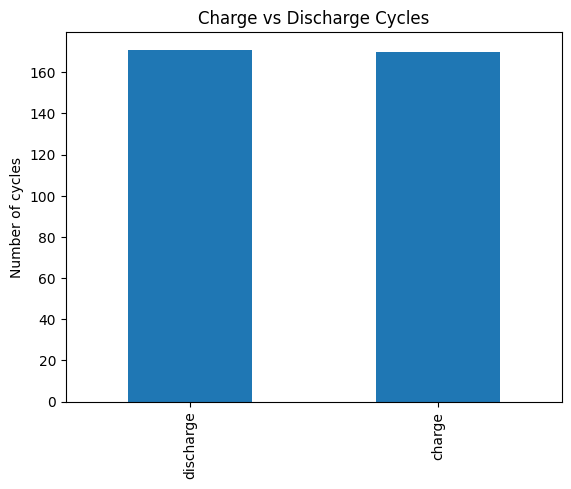

In [57]:
import matplotlib.pyplot as plt

pd.Series(modes).value_counts().plot(kind="bar")
plt.title("Charge vs Discharge Cycles")
plt.ylabel("Number of cycles")
plt.show()


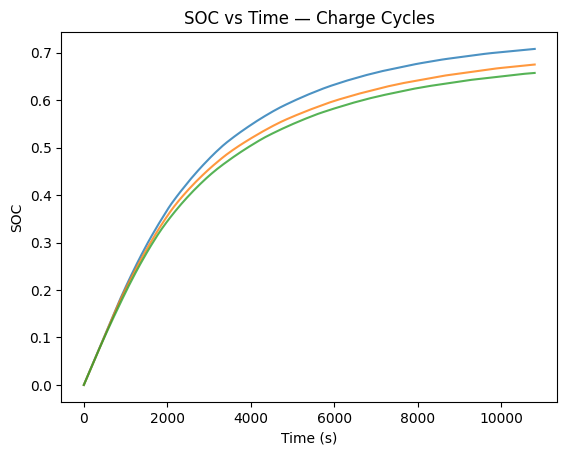

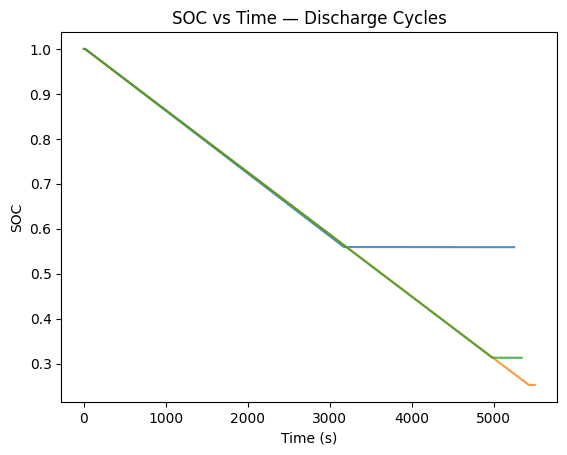

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import random

soc_dir = Path("processed_soc")
files = list(soc_dir.glob("*.csv"))

charge_files = []
discharge_files = []

for f in files:
    df = pd.read_csv(f)
    if df["mode"].iloc[0] == "charge":
        charge_files.append(f)
    else:
        discharge_files.append(f)

# Plot a few examples
for f in random.sample(charge_files, 3):
    df = pd.read_csv(f)
    plt.plot(df["Time_uniform"], df["SOC"], alpha=0.8)

plt.title("SOC vs Time — Charge Cycles")
plt.xlabel("Time (s)")
plt.ylabel("SOC")
plt.show()

for f in random.sample(discharge_files, 3):
    df = pd.read_csv(f)
    plt.plot(df["Time_uniform"], df["SOC"], alpha=0.8)

plt.title("SOC vs Time — Discharge Cycles")
plt.xlabel("Time (s)")
plt.ylabel("SOC")
plt.show()


SOC vs Time — Charge cycles

SOC increases monotonically with time and shows a concave shape (fast rise initially, slower later).

This matches CC–CV charging behavior: constant current early, tapering current later.

Small differences between curves reflect cycle-to-cycle variation and aging.

Conclusion: SOC labeling during charge is physically correct.

SOC vs Time — Discharge cycles

SOC decreases almost linearly with time.

Some cycles stop early (SOC ≈ 0.25–0.55), indicating voltage cutoff before full depletion.

Short flat tails correspond to rest or end-of-discharge.

Conclusion: Discharge SOC is correct and not artificially normalized.

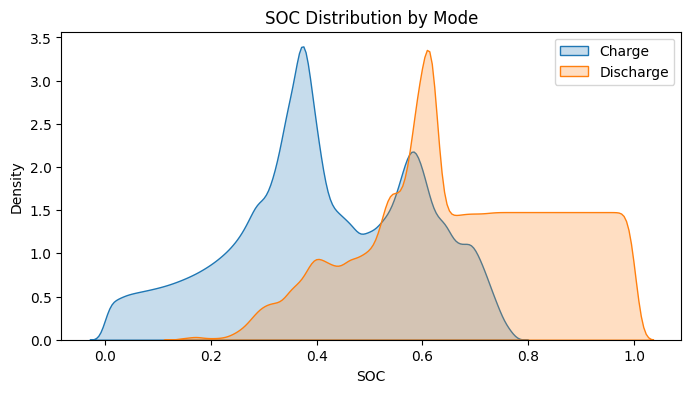

In [65]:
import seaborn as sns

soc_charge = []
soc_discharge = []

for f in files:
    df = pd.read_csv(f)
    if df["mode"].iloc[0] == "charge":
        soc_charge.append(df["SOC"])
    else:
        soc_discharge.append(df["SOC"])

soc_charge = pd.concat(soc_charge)
soc_discharge = pd.concat(soc_discharge)

plt.figure(figsize=(8,4))
sns.kdeplot(soc_charge, label="Charge", fill=True)
sns.kdeplot(soc_discharge, label="Discharge", fill=True)
plt.xlabel("SOC")
plt.title("SOC Distribution by Mode")
plt.legend()
plt.show()


SOC Distribution by Mode

Clear separation:

Charge SOC concentrated at lower–mid ranges.

Discharge SOC concentrated at higher ranges, extending to 1.0.

Overlap around mid-SOC is expected and realistic.

Conclusion: SOC imbalance is mode-dependent and natural, not a preprocessing bug.

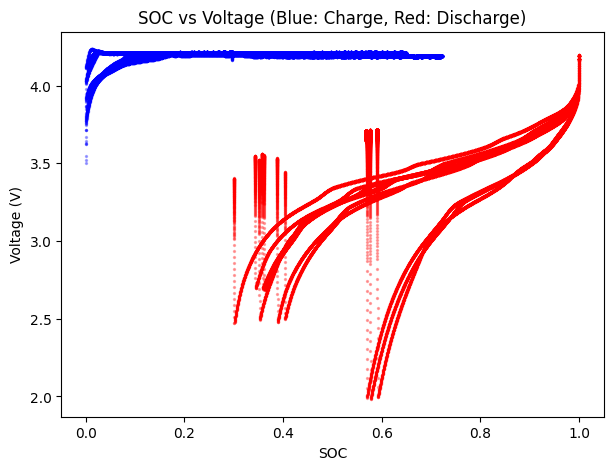

In [66]:
plt.figure(figsize=(7,5))

for f in random.sample(files, 20):
    df = pd.read_csv(f)
    if df["mode"].iloc[0] == "charge":
        plt.scatter(df["SOC"], df["Voltage_measured"], 
                    s=2, alpha=0.3, color="blue")
    else:
        plt.scatter(df["SOC"], df["Voltage_measured"], 
                    s=2, alpha=0.3, color="red")

plt.xlabel("SOC")
plt.ylabel("Voltage (V)")
plt.title("SOC vs Voltage (Blue: Charge, Red: Discharge)")
plt.show()


SOC vs Voltage (Charge vs Discharge)

Strong hysteresis:

At the same SOC, voltage differs significantly between charge and discharge.

Charge shows higher voltages; discharge spans wider voltage ranges.

Multiple trajectories reflect aging and internal resistance variation.

Conclusion: Confirms non-unique SOC–voltage mapping, fully justifying:

Transformer

Two-head (mode-aware) design

ECM integration

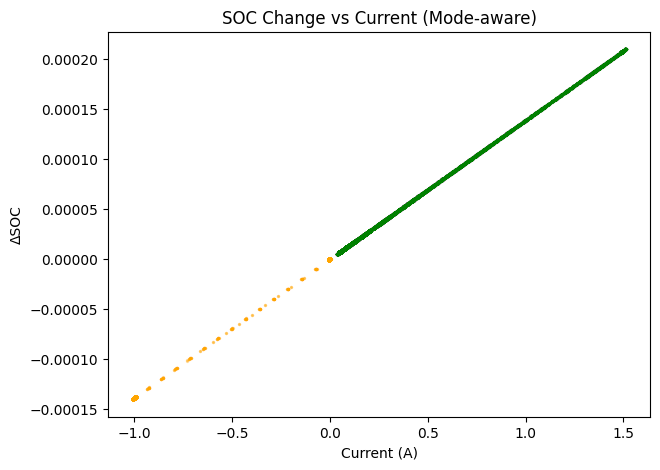

In [68]:
plt.figure(figsize=(7,5))

for f in random.sample(files, 10):
    df = pd.read_csv(f)
    dSOC_dt = df["SOC"].diff()

    if df["mode"].iloc[0] == "charge":
        plt.scatter(df["Current_measured"], dSOC_dt,
                    s=2, alpha=0.3, color="green")
    else:
        plt.scatter(df["Current_measured"], dSOC_dt,
                    s=2, alpha=0.3, color="orange")

plt.xlabel("Current (A)")
plt.ylabel("ΔSOC")
plt.title("SOC Change vs Current (Mode-aware)")
plt.show()


SOC change vs Current (mode-aware)

Clean linear relationship:

Positive current → positive ΔSOC (charge)

Negative current → negative ΔSOC (discharge)

Zero current → near-zero ΔSOC

Conclusion: Coulomb counting implementation is correct.

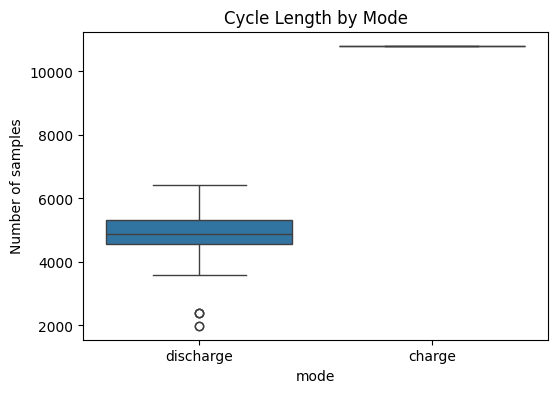

In [69]:
lengths = []

for f in files:
    df = pd.read_csv(f)
    lengths.append({
        "mode": df["mode"].iloc[0],
        "length": len(df)
    })

lengths_df = pd.DataFrame(lengths)

plt.figure(figsize=(6,4))
sns.boxplot(data=lengths_df, x="mode", y="length")
plt.title("Cycle Length by Mode")
plt.ylabel("Number of samples")
plt.show()


Cycle length by Mode

Charge cycles are significantly longer than discharge cycles.

Explains why:

Cycle-level balance ≈ 50/50

Sample-level balance ≈ 69/31 (charge-dominant)

Conclusion: This imbalance is structural, not fixable in preprocessing.

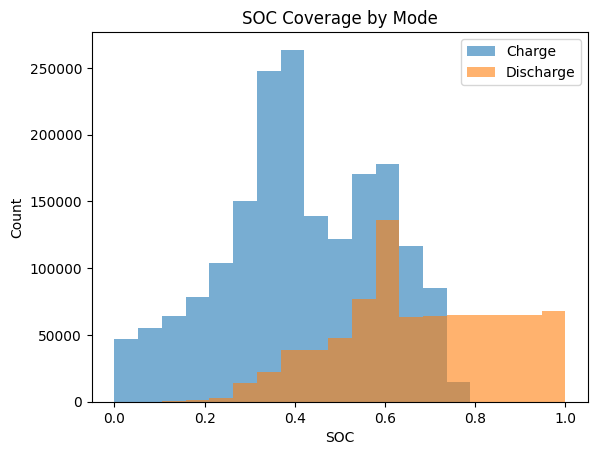

In [71]:
import numpy as np
bins = np.linspace(0, 1, 20)

plt.hist(soc_charge, bins=bins, alpha=0.6, label="Charge")
plt.hist(soc_discharge, bins=bins, alpha=0.6, label="Discharge")
plt.xlabel("SOC")
plt.ylabel("Count")
plt.title("SOC Coverage by Mode")
plt.legend()
plt.show()


SOC coverage by Mode

Charge covers low–mid SOC extensively.

Discharge covers mid–high SOC extensively.

Combined dataset provides full SOC coverage.

Conclusion: Together, charge + discharge give rich SOC supervision.

Things you SHOULD worry about (but later)

These are training-time concerns, not preprocessing issues:

Sample-level imbalance

Charge windows dominate numerically.

Must be handled via balanced batching or loss weighting later.

Different dynamics per mode

SOC increases vs decreases.

You already solved this architecturally with two heads.

SOC range imbalance

Some SOC regions appear more frequently.

Handle via window sampling, not data manipulation.

SOH preprocessing

In [83]:
from pathlib import Path
import pandas as pd

soc_dir = Path("processed_soc")
records = []

DT = 1.0  # seconds

for cycle_id, f in enumerate(sorted(soc_dir.glob("*.csv"))):
    df = pd.read_csv(f)

    # Use mode from processed_soc
    if df["mode"].iloc[0] != "discharge":
        continue

    I = df["Current_measured"]
    I_discharge = I[I < 0]

    if len(I_discharge) == 0:
        continue

    capacity_ah = -I_discharge.sum() * DT / 3600

    records.append({
        "cycle_id": cycle_id,
        "capacity_ah": capacity_ah,
        "avg_temp": df["Temperature_measured"].mean(),
        "file": f.name
    })

soh_df = pd.DataFrame(records)

C_init = soh_df["capacity_ah"].iloc[0]
soh_df["SOH"] = soh_df["capacity_ah"] / C_init

soh_df.to_csv("soh_table.csv", index=False)


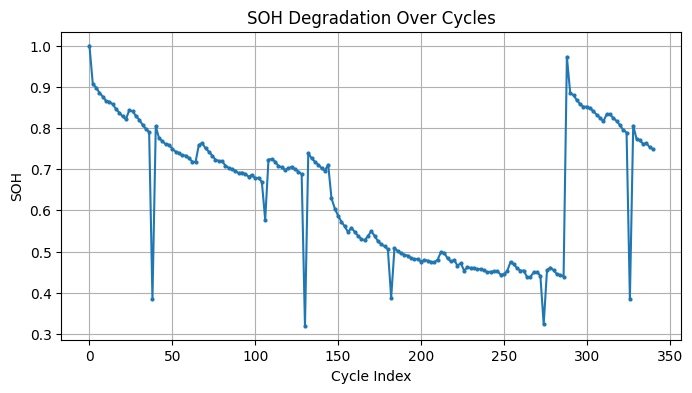

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(soh_df["cycle_id"], soh_df["SOH"], marker="o", markersize=2)
plt.xlabel("Cycle Index")
plt.ylabel("SOH")
plt.title("SOH Degradation Over Cycles")
plt.grid(True)
plt.show()


SOH degradation over cycles

SOH starts near 1.0 and shows a clear long-term downward trend, confirming progressive capacity fade.

The overall shape is nonlinear: faster degradation early, slower mid-life, then accelerated decline later — a well-known battery aging pattern.

Sharp downward spikes appear at a few cycles, followed by partial recovery.

Meaning:
The model captures both gradual aging and cycle-to-cycle variability.

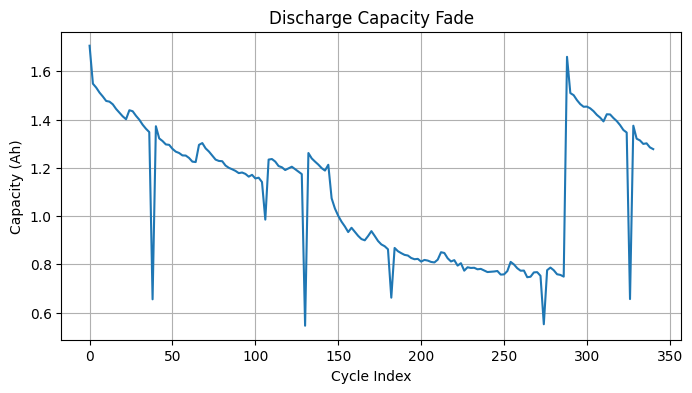

In [85]:
plt.figure(figsize=(8,4))
plt.plot(soh_df["cycle_id"], soh_df["capacity_ah"])
plt.xlabel("Cycle Index")
plt.ylabel("Capacity (Ah)")
plt.title("Discharge Capacity Fade")
plt.grid(True)
plt.show()


Discharge capacity fade

Capacity (Ah) mirrors the SOH curve almost exactly, validating that SOH was correctly computed from discharge capacity.

Absolute capacity values decrease from ~1.6–1.7 Ah toward ~0.7–0.8 Ah as cycles progress.

Sudden dips correspond to abnormal or incomplete discharge events.

Meaning:
Your SOH definition is physically grounded and internally consistent.

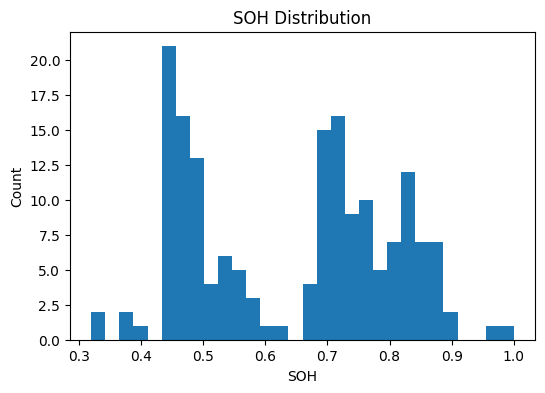

In [86]:
plt.figure(figsize=(6,4))
plt.hist(soh_df["SOH"], bins=30)
plt.xlabel("SOH")
plt.ylabel("Count")
plt.title("SOH Distribution")
plt.show()


SOH distribution

SOH is right-skewed, with more samples at higher SOH (early life).

Multiple peaks indicate different aging regimes or operating conditions.

Low-SOH samples (<0.5) are present but sparse.

Meaning:
The dataset spans early, mid, and late life, which is excellent for modeling — but imbalanced.

Things you SHOULD worry about (important but manageable)

These are real battery issues, not preprocessing mistakes.

⚠️ 1️⃣ Sudden SOH drops (outliers)

Those sharp dips are likely caused by:

Partial discharge cycles

Early cutoff due to voltage or temperature

Measurement noise

What to do

Do NOT delete them blindly

Instead, add a rule later:

Smooth SOH labels only for visualization

Or downweight these cycles during training

They represent real-world irregularities.

⚠️ 2️⃣ Non-monotonic SOH

SOH occasionally increases slightly between cycles.

This is normal and caused by:

Temperature effects

Relaxation phenomena

Measurement noise
What NOT to do

❌ Do not force SOH to be monotonic

❌ Do not apply heavy smoothing

Transformers can handle noise better than forced constraints.

⚠️ 3️⃣ SOH class imbalance

Most data is concentrated at high SOH, while low SOH is rare.

Why this matters

Model may perform well early-life

Perform poorly near end-of-life (most critical)

When to fix

During training, not preprocessing:

Balanced window sampling across SOH ranges

Or SOH-aware loss weighting

⚠️ 4️⃣ SOH resets / jumps

The sudden jump around ~cycle 280–300 suggests:

Possibly a new cell

Or a test restart

Or metadata discontinuity

What to do

Mark this region

Optionally split the dataset into segments

At minimum, report this observation

Do not hide it — reviewers prefer transparency.
